## **Importing Library**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objs as go
import plotly.subplots as sp
from plotly.subplots import make_subplots
from matplotlib import rcParams
# from plotly.offline import init_notebook_mode
# init_notebook_mode(connected=True)
import plotly.express as px
import warnings
import time
import datetime as dt
warnings.filterwarnings("ignore")
from typing import Optional, Tuple, List, Any
from datasets import load_dataset

## **Loading Jigsaw dataset**

In [ ]:
!pip install gdown

import gdown
import pandas as pd

# Download the file
file_id = "1bhKT_2MxolmG9TObFF7KQr0Ectvm6iNj"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "jigsaw_clean.csv", quiet=False)

# Load into pandas
df_jigsaw_clean = pd.read_csv("jigsaw_clean.csv")
print(df_jigsaw_clean.shape)
df_jigsaw_clean.head()

Downloading...
From (original): https://drive.google.com/uc?id=1bhKT_2MxolmG9TObFF7KQr0Ectvm6iNj
From (redirected): https://drive.google.com/uc?id=1bhKT_2MxolmG9TObFF7KQr0Ectvm6iNj&confirm=t&uuid=88e15cea-3623-4e26-a2b4-ad509a12efc0
To: /content/jigsaw_clean.csv
100%|██████████| 600M/600M [00:13<00:00, 43.2MB/s]


(1765331, 9)


,text,toxicity,severe_toxicity,obscene,threat,insult,identity_attack,sexual_explicit,word_count
0,"This is so cool. It's like, 'would you want yo...",0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.0,19
1,Thank you!! This would make my life a lot less...,0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.0,22
2,This is such an urgent design problem; kudos t...,0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.0,16
3,Is this something I'll be able to install on m...,0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.0,17
4,haha you guys are a bunch of losers.,0.893617,0.021277,0.0,0.0,0.87234,0.021277,0.0,8


## **Loading the Twitter dataset**

In [ ]:
## loading the twitter eval dataset into the system
file_id2 = "12ztcqKzK6wyE4eeXb_29QBUXHBrAC9iU"
url2 = f"https://drive.google.com/uc?id={file_id2}"
gdown.download(url2, "twitter_clean.csv", quiet=False)

df_twitter_clean = pd.read_csv("twitter_clean.csv")
print(df_twitter_clean.shape)
df_twitter_clean

Downloading...
From: https://drive.google.com/uc?id=12ztcqKzK6wyE4eeXb_29QBUXHBrAC9iU
To: /content/twitter_clean.csv
100%|██████████| 1.17M/1.17M [00:00<00:00, 36.8MB/s]

(8954, 3)


,text,label,word_count
0,@user nice new signage. Are you not concerned ...,0,16
1,A woman who you fucked multiple times saying y...,1,21
2,@user @user real talk do you have eyes or were...,1,16
3,your girlfriend lookin at me like a groupie in...,1,11
4,Hysterical woman like @user,0,4
...,...,...,...
8949,Oooohhhh bitch didn't even listen to the dead ...,0,18
8950,@user Good Luck @user More Americans #WalkAway...,0,20
8951,Bitch you can't keep up so stop trying,1,8
8952,@user @user @user @user @user @user Japan is a...,0,32


### **Combining both the datasets**

In [ ]:
# Adding the label column in the jigsaw dataset to match with the twitter dataset with a thrshold of 0.5
df_jigsaw_clean['label'] = (
    (df_jigsaw_clean[['toxicity', 'severe_toxicity', 'obscene',
                       'threat', 'insult', 'identity_attack',
                       'sexual_explicit']] >= 0.5).any(axis=1)
).astype(int)

df_jigsaw_final = df_jigsaw_clean[['text', 'label', 'word_count']].copy()
df_jigsaw_final['source'] = 'Jigsaw' ## adding the source column in the jigsaw dataset

df_twitter_final = df_twitter_clean[['text', 'label', 'word_count']].copy()
df_twitter_final['source'] = 'Twitter' ## adding the source column in the twitter dataset

 #Combining both the datasets based on the comman columns
df_combined = pd.concat([df_jigsaw_final, df_twitter_final], ignore_index=True)
df_combined



,text,label,word_count,source
0,"This is so cool. It's like, 'would you want yo...",0,19,Jigsaw
1,Thank you!! This would make my life a lot less...,0,22,Jigsaw
2,This is such an urgent design problem; kudos t...,0,16,Jigsaw
3,Is this something I'll be able to install on m...,0,17,Jigsaw
4,haha you guys are a bunch of losers.,1,8,Jigsaw
...,...,...,...,...
1774280,Oooohhhh bitch didn't even listen to the dead ...,0,18,Twitter
1774281,@user Good Luck @user More Americans #WalkAway...,0,20,Twitter
1774282,Bitch you can't keep up so stop trying,1,8,Twitter
1774283,@user @user @user @user @user @user Japan is a...,0,32,Twitter


#### **Visualiztion - 1 Class Distribution Comparison to identify the imbalance between the datasets**


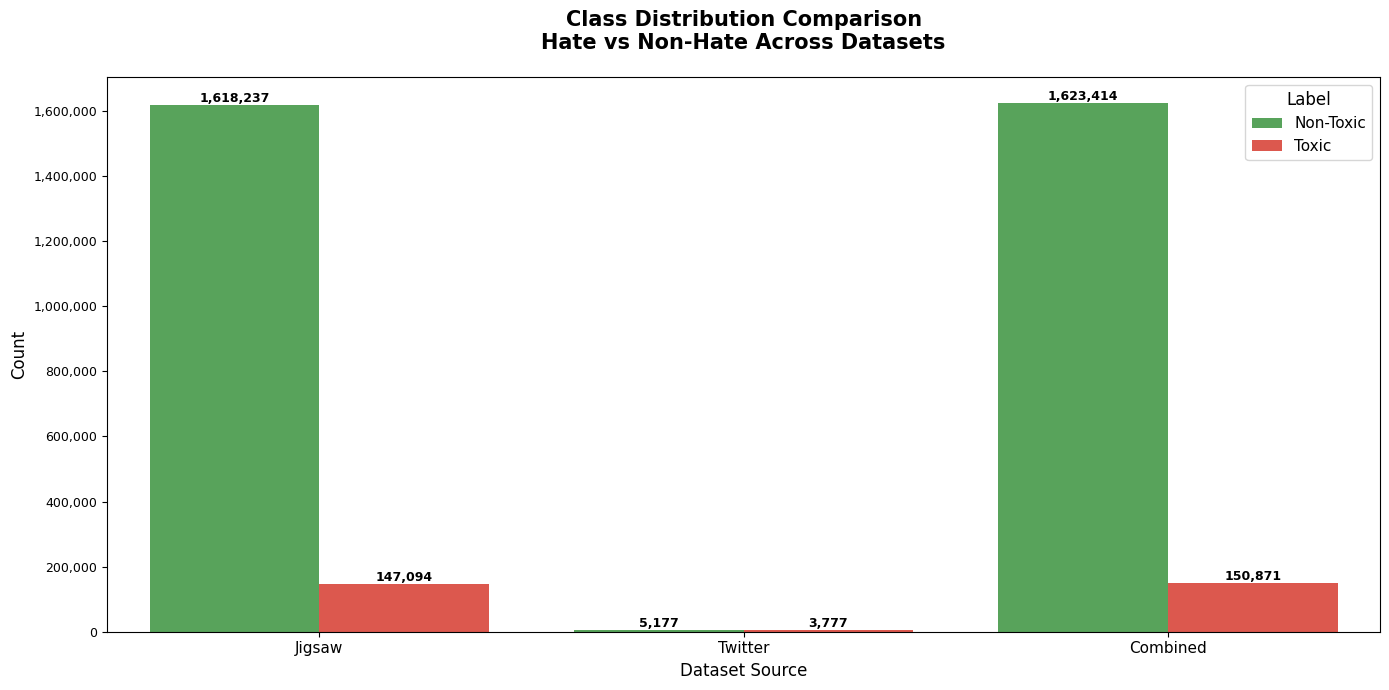

In [ ]:
# Step 4: Get label counts per dataset
jigsaw_counts = df_jigsaw_final['label'].value_counts().reset_index()
jigsaw_counts.columns = ['label', 'count']
jigsaw_counts['source'] = 'Jigsaw'

twitter_counts = df_twitter_final['label'].value_counts().reset_index()
twitter_counts.columns = ['label', 'count']
twitter_counts['source'] = 'Twitter'

combined_counts = df_combined['label'].value_counts().reset_index()
combined_counts.columns = ['label', 'count']
combined_counts['source'] = 'Combined'

#  Merge all counts
all_counts = pd.concat([jigsaw_counts, twitter_counts, combined_counts], ignore_index=True)
all_counts['label'] = all_counts['label'].map({0: 'Non-Toxic', 1: 'Toxic'})

#  Plot
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=all_counts, x='source', y='count', hue='label',
                 palette={'Non-Toxic': '#4CAF50', 'Toxic': '#F44336'})

plt.title('Class Distribution Comparison\nHate vs Non-Hate Across Datasets',
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Dataset Source', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Label', fontsize=11, title_fontsize=12)
plt.xticks(fontsize=11)

# adjust y-axis to show proper numbers instead of scientific notation
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(fontsize=11)
plt.yticks(fontsize=9)

# Add value labels on top of bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height()):,}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

#### Insights
**Heavy Class Imbalance**: Non-toxic samples dominate all three datasets
making this a highly imbalanced classification problem.


**Jigsaw is Non-Toxic Heavy**: Out of 1,765,331 samples, 1,618,237 (91.7%) are non-toxic and only 147,094 (8.3%) are toxic.




#### **Visualiztion - 2  Text Length Distribution by Dataset**


In [ ]:
## checking the source column in the combined dataset
print(df_combined['source'].value_counts())


source
Jigsaw     1765331
Twitter       8954
Name: count, dtype: int64


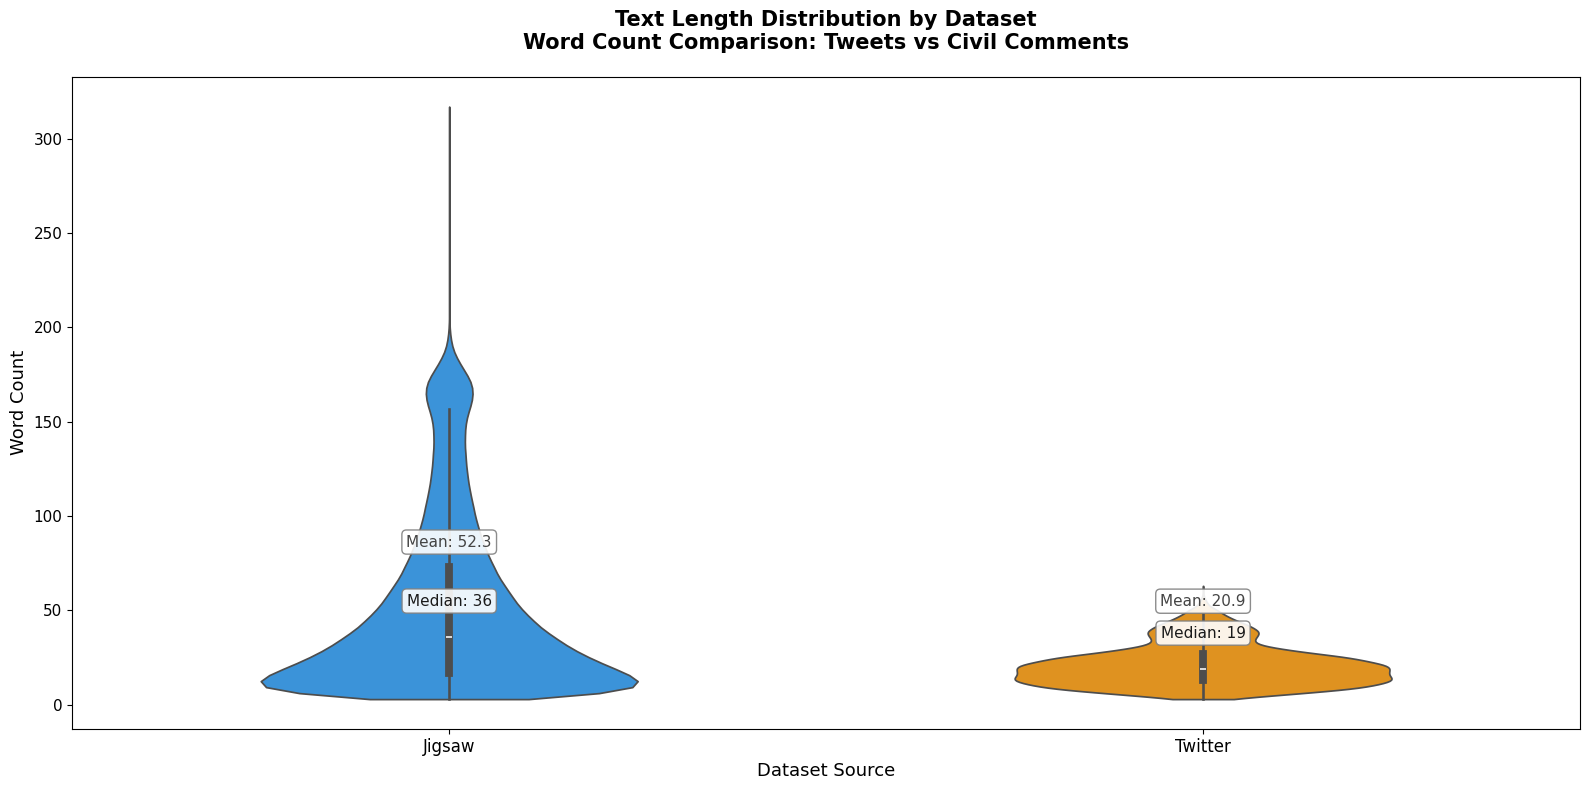

In [ ]:
fig, ax = plt.subplots(figsize=(16, 8))  # wider figure

sns.violinplot(data=df_combined, x='source', y='word_count',
               hue='source',
               palette={'Jigsaw': '#2196F3', 'Twitter': '#FF9800'},
               inner='box',
               cut=0,
               width=0.5,
               ax=ax)

plt.title('Text Length Distribution by Dataset\nWord Count Comparison: Tweets vs Civil Comments',
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Dataset Source', fontsize=13)
plt.ylabel('Word Count', fontsize=13)
plt.xticks(fontsize=12)
plt.yticks(fontsize=11)

# place ABOVE the median/mean points
for i, source in enumerate(['Jigsaw', 'Twitter']):
    median = df_combined[df_combined['source'] == source]['word_count'].median()
    mean = df_combined[df_combined['source'] == source]['word_count'].mean()

    ax.text(i, median + 15, f'Median: {median:.0f}',
            ha='center', va='bottom', fontsize=11,
             color='#1a1a1a',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='gray', alpha=0.9))

    ax.text(i, mean + 30, f'Mean: {mean:.1f}',
            ha='center', va='bottom', fontsize=11,
            color='#444444',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='gray', alpha=0.9))

plt.tight_layout()
plt.show()

#### Insights
**Jigsaw texts are significantly longer**: Jigsaw has a median of 36 words and mean of 52 words, meaning civil comments tend to be detailed and explanatory in nature.

**Twitter texts are much shorter**: Twitter has a median of 19 words and mean of 20 words, which aligns with Twitter's character limit forcing users to be brief.

**Jigsaw has high variance in text length**: The tall and wide violin shape tells us that Jigsaw texts range from very short to 300+ words, meaning some users write very lengthy comments.

#### **Visualization -3 Text Length by Label.**
To determine whether hate messages differ in length from non-hate messages.



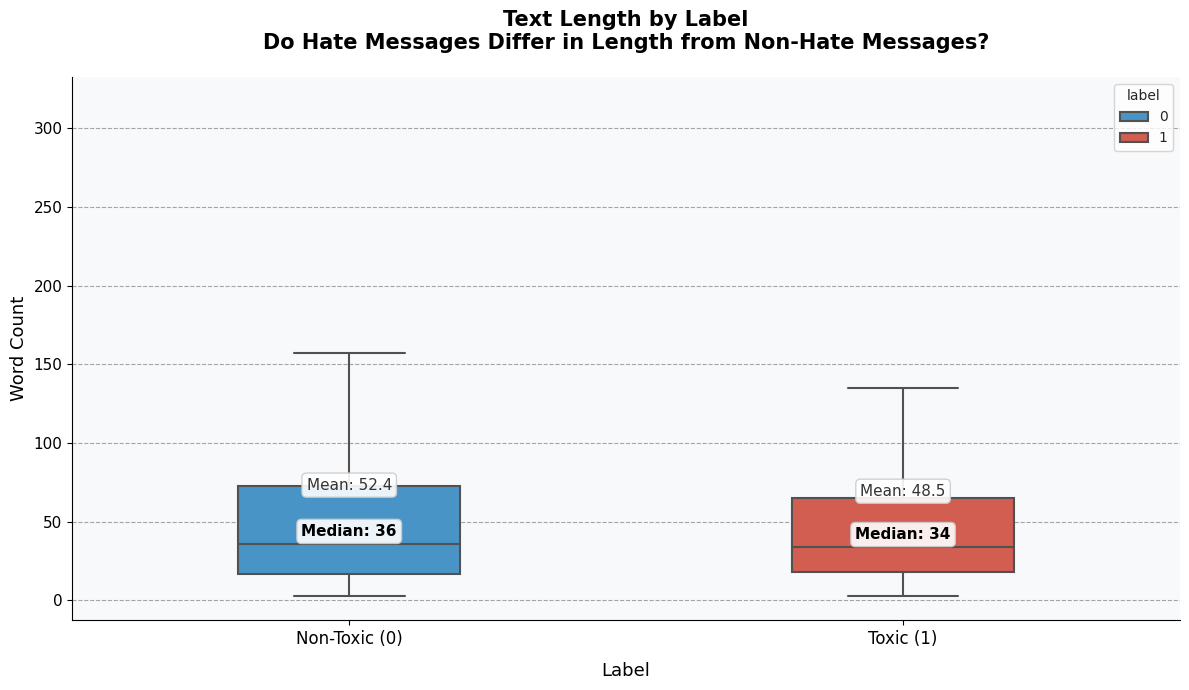

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

# Set clean background
sns.set_style("whitegrid")

# Plot Boxplot
sns.boxplot(data=df_combined, x='label', y='word_count',
            hue='label',
            palette={0: '#3498DB', 1: '#E74C3C'},
            width=0.4,
            linewidth=1.5,
            fliersize=0,       # removes outlier dots for cleaner look
            ax=ax)

# Light background color
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('#FFFFFF')

# Add subtle grid
ax.yaxis.grid(True, linestyle='--', alpha=0.7, color='gray')
ax.set_axisbelow(True)

plt.title('Text Length by Label\nDo Hate Messages Differ in Length from Non-Hate Messages?',
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Label', fontsize=13, labelpad=10)
plt.ylabel('Word Count', fontsize=13)
plt.xticks(ticks=[0, 1], labels=['Non-Toxic (0)', 'Toxic (1)'], fontsize=12)
plt.yticks(fontsize=11)

# Remove top and right spines
sns.despine()

# Add median and mean labels
for i, label in enumerate([0, 1]):
    median = df_combined[df_combined['label'] == label]['word_count'].median()
    mean = df_combined[df_combined['label'] == label]['word_count'].mean()

    ax.text(i, median + 5, f'Median: {median:.0f}',
            ha='center', fontsize=11, fontweight='bold', color='black',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#cccccc', alpha=0.9))

    ax.text(i, mean + 18, f'Mean: {mean:.1f}',
            ha='center', fontsize=11, color='#333333',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#cccccc', alpha=0.9))

plt.tight_layout()
plt.show()

#### Insights
**Similar text length** — Non-Toxic (median: 36) and Toxic (median: 34) are very close, meaning length alone can't distinguish hate speech.

**Word count is a weak feature** — Cannot be used alone to detect toxic content.

#### **Visualiztion-4 Toxicity Score Distribution**
To visualize continuous toxicity score distribution before thresholding (0.5)

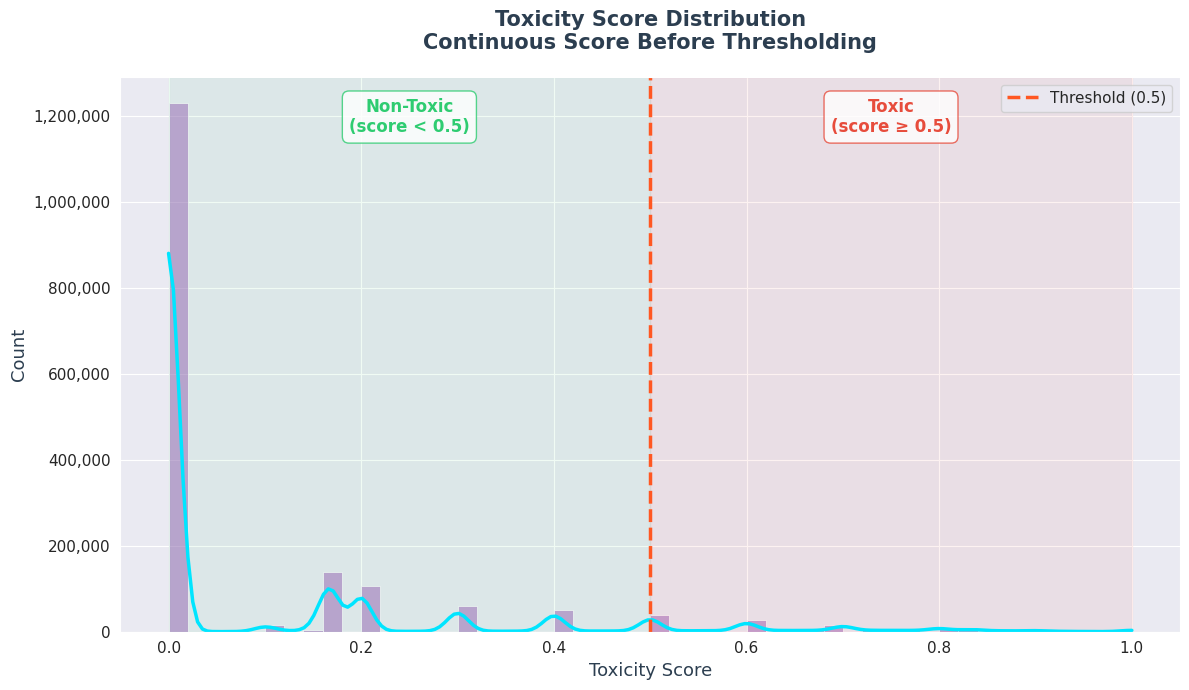

In [ ]:
sns.set_style("darkgrid")

fig, ax = plt.subplots(figsize=(12, 7))

# Plot histogram with gradient purple color
sns.histplot(data=df_jigsaw_clean, x='toxicity',
             bins=50,
             color='#9B59B6',      # purple
             edgecolor='#FFFFFF',
             linewidth=0.5,
             kde=True,
             ax=ax)


ax.lines[0].set_color('#00E5FF')
ax.lines[0].set_linewidth(2.5)

# Threshold line in bright orange
ax.axvline(x=0.5, color='#FF5722', linewidth=2.5,
           linestyle='--', label='Threshold (0.5)')

# Fill under threshold areas
ax.axvspan(0, 0.5, alpha=0.07, color='#2ECC71')    # green shade = non toxic
ax.axvspan(0.5, 1, alpha=0.07, color='#E74C3C')    # red shade = toxic

plt.title('Toxicity Score Distribution\nContinuous Score Before Thresholding',
          fontsize=15, fontweight='bold', pad=20, color='#2C3E50')
plt.xlabel('Toxicity Score', fontsize=13, color='#2C3E50')
plt.ylabel('Count', fontsize=13, color='#2C3E50')
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(fontsize=11)

# Adjust y-axis
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Add text annotations
ax.text(0.25, ax.get_ylim()[1] * 0.9, 'Non-Toxic\n(score < 0.5)',
        ha='center', fontsize=12, color='#2ECC71', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='#2ECC71', alpha=0.8))

ax.text(0.75, ax.get_ylim()[1] * 0.9, 'Toxic\n(score ≥ 0.5)',
        ha='center', fontsize=12, color='#E74C3C', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='#E74C3C', alpha=0.8))

plt.tight_layout()
plt.show()

###Insights
 **Non-Toxic dominates**: Almost all texts fall in the green zone (score < 0.5), confirming the class imbalance we saw earlier (~91.5% non-toxic).

 The **Jigsaw dataset** is overwhelmingly non-toxic — most comments scored close to 0, and only a tiny fraction crossed the 0.5 toxic threshold

#### **visualization-5 Toxic Label Correlation**
To analyze relationships between toxicity-related features.

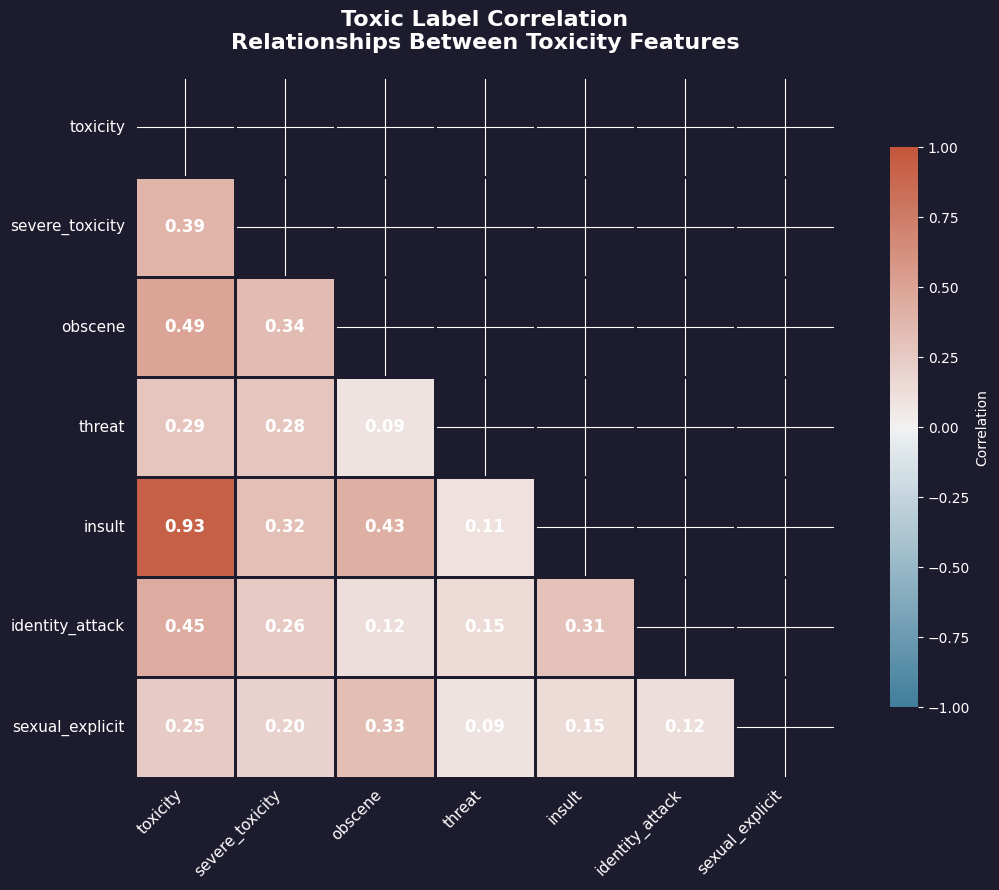

In [ ]:
toxic_cols = ['toxicity', 'severe_toxicity', 'obscene',
              'threat', 'insult', 'identity_attack', 'sexual_explicit']

#  Compute correlation matrix
corr_matrix = df_jigsaw_clean[toxic_cols].corr()

#  Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

#  Plot
fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor('#1C1C2E')   # dark background
ax.set_facecolor('#1C1C2E')

# Custom colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr_matrix,
            mask=mask,               # show only lower triangle
            annot=True,
            fmt='.2f',
            cmap=cmap,
            center=0,
            linewidths=2,
            linecolor='#1C1C2E',     # dark lines between cells
            square=True,
            annot_kws={'size': 12, 'fontweight': 'bold', 'color': 'white'},
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
            vmin=-1, vmax=1,
            ax=ax)

# Style title and labels
plt.title('Toxic Label Correlation\nRelationships Between Toxicity Features',
          fontsize=16, fontweight='bold', pad=20, color='white')
plt.xticks(fontsize=11, rotation=45, ha='right', color='white')
plt.yticks(fontsize=11, rotation=0, color='white')

# Style colorbar
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_color('white')
cbar.ax.tick_params(colors='white')

plt.tight_layout()
plt.show()

### Insights
**Toxicity & Insult are strongly correlated (0.93)**: This is the strongest relationship in the entire heatmap — meaning if a text is insulting, it is almost always toxic too. These two features are nearly identical.


 **Toxicity & Obscene are moderately correlated** **(0.49)**: Obscene language is a common contributor to toxicity but not always present.


**Toxicity & Identity Attack are moderately correlated (0.45)**: Identity-based attacks (race, religion, gender) are a significant but not dominant driver of toxicity.


 **Severe Toxicity & Toxicity are correlated (0.39)**: Severe toxicity is a subset of general toxicity — not all toxic texts are severely toxic.

 **Threat is weakly correlated with everything**: Threat has the lowest correlations across all features (0.09-0.29), meaning threatening language occurs independently of other toxic behaviors.

 **Sexual Explicit is weakly correlated (0.09-0.33)**: Sexual content appears independently from most other toxicity types.


 **Insult is redundant with Toxicity**: Since insult correlates 0.93 with toxicity, using both features in a model would be redundant that is one can be dropped.



### **Viusaliztion-6  Top Unigram Frequency (Hate Class)**
To identify most frequent words in hate content.



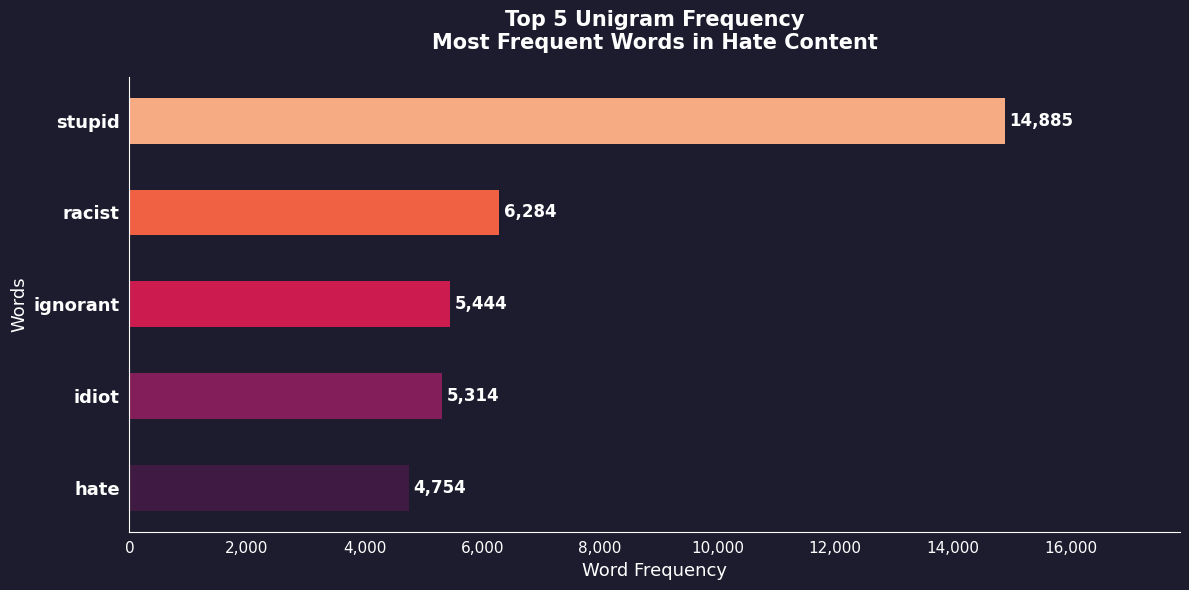

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

#  Filter only toxic texts
toxic_texts = df_combined[df_combined['label'] == 1]['text'].dropna()

# Extended stop words
custom_stopwords = list(ENGLISH_STOP_WORDS) + [
    'just', 'like', 'people', 'don', 'think', 'know', 'right',
    'time', 'did', 'make', 'good', 'want', 'way', 'really',
    'say', 'said', 'got', 'get', 'going', 'come', 'use', 'used',
    'thing', 'things', 'does', 'look', 'let', 'need', 'even',
    'still', 'back', 'tell', 'new', 'try', 'yeah', 'yes',
    'lot', 'left', 'true', 'better', 'believe', 'stop',
    'http', 'https', 'rt', 'amp', 'co', 've', 'll',
    'isn', 'aren', 'user', 'didn',
    'trump', 'obama', 'president', 'country', 'government',
    'canada', 'america', 'american', 'state', 'world',
    'hillary', 'liberal', 'party', 'vote',
    'years', 'man', 'money', 'great', 'women', 'person',
    'white', 'black', 'doesn', 'old', 'little',
    'life', 'real', 'day', 'work', 'fact'
]

#  Apply CountVectorizer - top 5 only
vectorizer = CountVectorizer(max_features=5,
                             stop_words=custom_stopwords,
                             ngram_range=(1, 1))

X = vectorizer.fit_transform(toxic_texts)

#  Aggregate word counts
word_counts = X.sum(axis=0)
words_df = pd.DataFrame({'word': vectorizer.get_feature_names_out(),
                         'count': word_counts.A1})
words_df = words_df.sort_values('count', ascending=True)

# Plot
sns.set_style('dark')
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#1C1C2E')
ax.set_facecolor('#1C1C2E')

bars = ax.barh(words_df['word'], words_df['count'],
               color=sns.color_palette('rocket', len(words_df)),
               edgecolor='none',
               height=0.5)

# Remove grids
ax.grid(False)

# Count labels
for bar, count in zip(bars, words_df['count']):
    ax.text(bar.get_width() + 80, bar.get_y() + bar.get_height()/2,
            f'{int(count):,}',
            va='center', fontsize=12, color='white', fontweight='bold')

# Extend x axis
ax.set_xlim(0, words_df['count'].max() * 1.2)

plt.title('Top 5 Unigram Frequency\nMost Frequent Words in Hate Content',
          fontsize=15, fontweight='bold', pad=20, color='white')
plt.xlabel('Word Frequency', fontsize=13, color='white')
plt.ylabel('Words', fontsize=13, color='white')
plt.xticks(fontsize=11, color='white')
plt.yticks(fontsize=13, color='white', fontweight='bold')

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('white')
ax.spines['bottom'].set_color('white')

plt.tight_layout()
plt.show()

#### Insights

**"Stupid" dominates (14,885):** The most used hate word by far — appearing more than double any other word, showing personal insults are the most common form of toxic content.


 **"Racist" is second (6,284):** A direct identity-based attack word, confirming that race-related hate speech is very prevalent in toxic content.


**"Ignorant" and "Idiot" are close (5,444 vs 5,314)**: Both are personal insults targeting intelligence, suggesting toxic users commonly attack people's intellect.


 **"Hate" itself appears (4,754)**: People explicitly express hatred in toxic texts, making it a strong signal word for hate speech detection.

### **Visualization -7 Word cloud comparison Hate vs Not Hate**

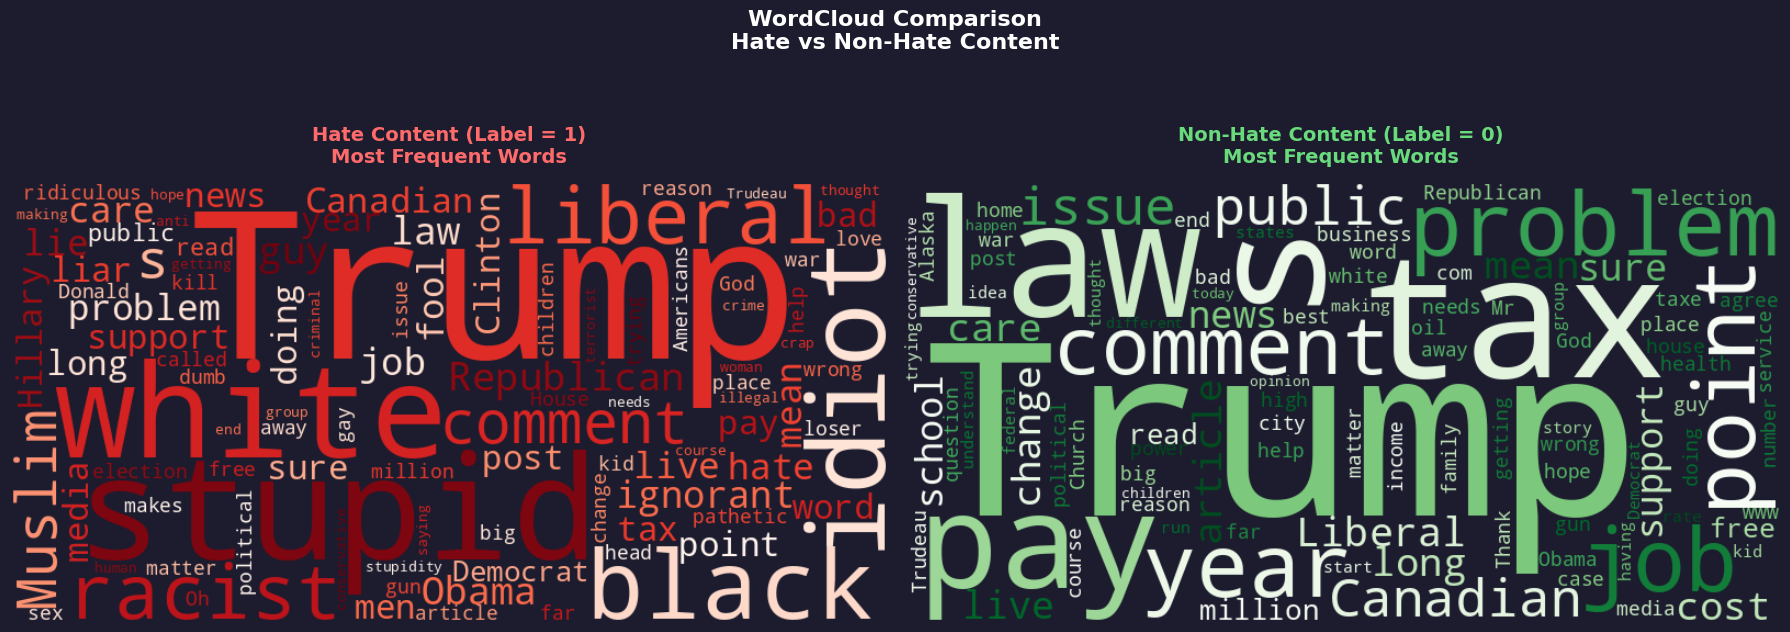

In [ ]:
from wordcloud import WordCloud
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import matplotlib.pyplot as plt

#  Filter texts by label
toxic_texts = ' '.join(df_combined[df_combined['label'] == 1]['text'].dropna())
nontoxic_texts = ' '.join(df_combined[df_combined['label'] == 0]['text'].dropna())

#  Extended stop words - added don't and can't
custom_stopwords = set(ENGLISH_STOP_WORDS).union({
    'just', 'like', 'people', 'don', 'think', 'know', 'right',
    'time', 'did', 'make', 'good', 'want', 'way', 'really',
    'say', 'said', 'got', 'get', 'going', 'come', 'use', 'used',
    'thing', 'things', 'does', 'look', 'let', 'need', 'even',
    'still', 'back', 'tell', 'new', 'try', 'yeah', 'yes',
    'lot', 'left', 'true', 'better', 'believe', 'stop',
    'http', 'https', 'rt', 'amp', 'co', 've', 'll',
    'isn', 'aren', 'user', 'didn',
    'president', 'country', 'government', 'canada',
    'america', 'american', 'state', 'world',
     'party', 'vote', 'years', 'man', 'money',
    'great', 'women', 'person',   'doesn',
    'old', 'little', 'life', 'real', 'day', 'work', 'fact',
    # Newly added
    "don't", "can't", "dont", "cant", "doesn't", "isn't",
    "aren't", "didn't", "won't", "i'm", "you're", "it's",
    "that's", "they're", "we're", "i've", "would", "could",
    "should", "maybe", "actually", "though", "also"
})

#  Generate WordClouds
wc_toxic = WordCloud(width=800, height=400,
                     background_color='#1C1C2E',
                     colormap='Reds',
                     stopwords=custom_stopwords,
                     max_words=100,
                     collocations=False).generate(toxic_texts)

wc_nontoxic = WordCloud(width=800, height=400,
                        background_color='#1C1C2E',
                        colormap='Greens',
                        stopwords=custom_stopwords,
                        max_words=100,
                        collocations=False).generate(nontoxic_texts)

#  Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('#1C1C2E')

# Toxic WordCloud
axes[0].imshow(wc_toxic, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Hate Content (Label = 1)\nMost Frequent Words',
                  fontsize=14, fontweight='bold', color='#FF6B6B', pad=15)

# Non-Toxic WordCloud
axes[1].imshow(wc_nontoxic, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Non-Hate Content (Label = 0)\nMost Frequent Words',
                  fontsize=14, fontweight='bold', color='#69DB7C', pad=15)

plt.suptitle('WordCloud Comparison\nHate vs Non-Hate Content',
             fontsize=16, fontweight='bold', color='white', y=1.02)

plt.tight_layout()
plt.show()

### Insights
**Stupid", "Idiot", "Ignorant" are the biggest words** — hate content is dominated by direct personal insults

**"Racist", "Hate", "Fool", "Loser", "Liar"** — wide variety of attack vocabulary

 **"Trump", "White", "Black", "Muslim", "Liberal"** — hate is strongly politically and racially targeted

**"Kill", "Terrorist", "Criminal", "Illegal"** — some toxic content contains threatening and dangerous language

###**Visualisation-8 Vocabulary Overlap**
To measure domain shift by comparing unique vocabulary and overlap between Jigsaw comments and TweetEval tweets.


In [ ]:
!pip install matplotlib-venn

In [ ]:
from matplotlib_venn import venn2, venn2_circles
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import matplotlib.pyplot as plt
import re

#  Clean and tokenize function
def clean_tokenize(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)        # remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)   # remove punctuation
    tokens = text.split()
    return tokens

#  Build vocabulary sets
print("Building Jigsaw vocabulary...")
jigsaw_vocab = set()
for text in df_jigsaw_final['text'].dropna():
    jigsaw_vocab.update(clean_tokenize(text))

print("Building Twitter vocabulary...")
twitter_vocab = set()
for text in df_twitter_final['text'].dropna():
    twitter_vocab.update(clean_tokenize(text))

#  Compute stats
overlap = jigsaw_vocab.intersection(twitter_vocab)
jigsaw_only = jigsaw_vocab - twitter_vocab
twitter_only = twitter_vocab - jigsaw_vocab
total = jigsaw_vocab.union(twitter_vocab)

print(f"\nJigsaw vocabulary size:  {len(jigsaw_vocab):,}")
print(f"Twitter vocabulary size: {len(twitter_vocab):,}")
print(f"Shared words:            {len(overlap):,}")
print(f"Jigsaw only:             {len(jigsaw_only):,}")
print(f"Twitter only:            {len(twitter_only):,}")
print(f"Overlap %:               {len(overlap)/len(total)*100:.1f}%")

Building Jigsaw vocabulary...
Building Twitter vocabulary...

Jigsaw vocabulary size:  538,531
Twitter vocabulary size: 17,726
Shared words:            13,927
Jigsaw only:             524,604
Twitter only:            3,799
Overlap %:               2.6%


Circle 1 center: [-0.01632081  0.        ]
Circle 2 center: [0.49584 0.     ]


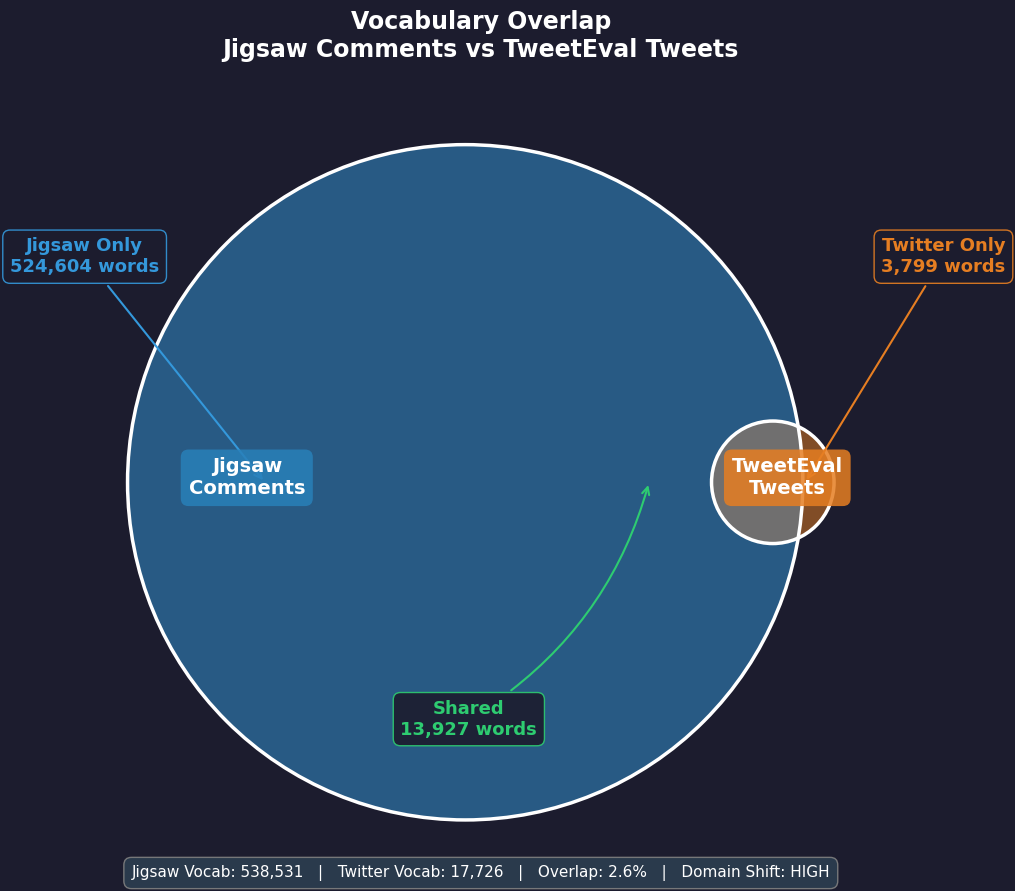

In [ ]:
from matplotlib_venn import venn2, venn2_circles
import matplotlib.pyplot as plt

#  Plot
fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor('#1C1C2E')
ax.set_facecolor('#1C1C2E')

#  Draw Venn
venn = venn2([jigsaw_vocab, twitter_vocab],
             set_labels=('', ''),
             set_colors=('#3498DB', '#E67E22'),
             alpha=0.5,
             ax=ax)

#  Circle borders
venn_c = venn2_circles([jigsaw_vocab, twitter_vocab],
                        linewidth=2.5,
                        color='white',
                        ax=ax)

#  Clear default labels
for label_id in ['10', '01', '11']:
    lbl = venn.get_label_by_id(label_id)
    if lbl:
        lbl.set_text('')

#  Find exact intersection center
c1 = venn_c[0].center
c2 = venn_c[1].center
print(f"Circle 1 center: {c1}")
print(f"Circle 2 center: {c2}")

# Intersection is approximately between the two circle edges
intersect_x = (c1[0] + c2[0]) / 2 + 0.05
intersect_y = 0.0

# Jigsaw only
ax.annotate(f'Jigsaw Only\n{len(jigsaw_only):,} words',
            xy=(-0.35, 0), xytext=(-0.65, 0.35),
            fontsize=13, fontweight='bold', color='#3498DB',
            ha='center',
            arrowprops=dict(arrowstyle='->', color='#3498DB', lw=1.5),
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#1C1C2E',
                      edgecolor='#3498DB', alpha=0.9))

# Twitter only
ax.annotate(f'Twitter Only\n{len(twitter_only):,} words',
            xy=(0.55, 0), xytext=(0.78, 0.35),
            fontsize=13, fontweight='bold', color='#E67E22',
            ha='center',
            arrowprops=dict(arrowstyle='->', color='#E67E22', lw=1.5),
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#1C1C2E',
                      edgecolor='#E67E22', alpha=0.9))


ax.annotate(f'Shared\n{len(overlap):,} words',
            xy=(intersect_x, intersect_y),  # intersection point
            xytext=(intersect_x - 0.3, -0.42),  # label below left
            fontsize=13, fontweight='bold', color='#2ECC71',
            ha='center',
            arrowprops=dict(arrowstyle='->', color='#2ECC71',
                           lw=1.5, connectionstyle='arc3,rad=0.2'),
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#1C1C2E',
                      edgecolor='#2ECC71', alpha=0.9))

# Dataset name labels
ax.text(-0.38, -0.02, 'Jigsaw\nComments',
        ha='center', fontsize=14, fontweight='bold',
        color='white',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#2980B9',
                  edgecolor='none', alpha=0.85))

ax.text(0.52, -0.02, 'TweetEval\nTweets',
        ha='center', fontsize=14, fontweight='bold',
        color='white',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#E67E22',
                  edgecolor='none', alpha=0.85))

#  Stats box
overlap_pct = len(overlap)/len(total)*100
domain_shift = "HIGH" if overlap_pct < 20 else "LOW"
stats_text = (f"Jigsaw Vocab: {len(jigsaw_vocab):,}   |   "
              f"Twitter Vocab: {len(twitter_vocab):,}   |   "
              f"Overlap: {overlap_pct:.1f}%   |   "
              f"Domain Shift: {domain_shift}")

fig.text(0.5, 0.02, stats_text,
         ha='center', fontsize=11, color='white',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#2C3E50',
                   edgecolor='gray', alpha=0.9))

plt.title('Vocabulary Overlap\nJigsaw Comments vs TweetEval Tweets',
          fontsize=17, fontweight='bold', color='white', pad=20)

plt.tight_layout()
plt.show()

###Insights
 **Only 2.6% overlap (13,927 words)**: The two datasets share very few common words  meaning they use completely different language styles.

 **Domain Shift is High**: The model trained on Jigsaw will struggle on Twitter because: jigsaw uses formal, longer sentences
         Twitter uses slang, abbreviations, @mentions, hashtags

**Model implication**: A model trained only on Jigsaw will likely perform poorly on Twitter data due to high domain shift this is why combining both datasets for training is important.


## **Loading the Preprocessed Dataset**

In [3]:
import gdown


# Download the file
file_id = "1hZ9ikt7OzyShzHJxJ5JTvF4kfIb492zA"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "preprocessed_dataset.csv", quiet=False)

# Load into pandas
df_preprocessed = pd.read_csv("preprocessed_dataset.csv")

print("Shape:", df_preprocessed.shape)
print("\nColumns:", df_preprocessed.columns.tolist())
print("\nFirst few rows:")
df_preprocessed.head()

Downloading...
From (original): https://drive.google.com/uc?id=1hZ9ikt7OzyShzHJxJ5JTvF4kfIb492zA
From (redirected): https://drive.google.com/uc?id=1hZ9ikt7OzyShzHJxJ5JTvF4kfIb492zA&confirm=t&uuid=dd5c490c-dce6-4ee8-a9aa-0a060e8d6fa9
To: /content/preprocessed_dataset.csv
100%|██████████| 234M/234M [00:02<00:00, 103MB/s]


Shape: (58954, 200)

Columns: ['SVD_0', 'SVD_1', 'SVD_2', 'SVD_3', 'SVD_4', 'SVD_5', 'SVD_6', 'SVD_7', 'SVD_8', 'SVD_9', 'SVD_10', 'SVD_11', 'SVD_12', 'SVD_13', 'SVD_14', 'SVD_15', 'SVD_16', 'SVD_17', 'SVD_18', 'SVD_19', 'SVD_20', 'SVD_21', 'SVD_22', 'SVD_23', 'SVD_24', 'SVD_25', 'SVD_26', 'SVD_27', 'SVD_28', 'SVD_29', 'SVD_30', 'SVD_31', 'SVD_32', 'SVD_33', 'SVD_34', 'SVD_35', 'SVD_36', 'SVD_37', 'SVD_38', 'SVD_39', 'SVD_40', 'SVD_41', 'SVD_42', 'SVD_43', 'SVD_44', 'SVD_45', 'SVD_46', 'SVD_47', 'SVD_48', 'SVD_49', 'SVD_50', 'SVD_51', 'SVD_52', 'SVD_53', 'SVD_54', 'SVD_55', 'SVD_56', 'SVD_57', 'SVD_58', 'SVD_59', 'SVD_60', 'SVD_61', 'SVD_62', 'SVD_63', 'SVD_64', 'SVD_65', 'SVD_66', 'SVD_67', 'SVD_68', 'SVD_69', 'SVD_70', 'SVD_71', 'SVD_72', 'SVD_73', 'SVD_74', 'SVD_75', 'SVD_76', 'SVD_77', 'SVD_78', 'SVD_79', 'SVD_80', 'SVD_81', 'SVD_82', 'SVD_83', 'SVD_84', 'SVD_85', 'SVD_86', 'SVD_87', 'SVD_88', 'SVD_89', 'SVD_90', 'SVD_91', 'SVD_92', 'SVD_93', 'SVD_94', 'SVD_95', 'SVD_96', 'SVD_97',

,SVD_0,SVD_1,SVD_2,SVD_3,SVD_4,SVD_5,SVD_6,SVD_7,SVD_8,SVD_9,...,SVD_190,SVD_191,SVD_192,SVD_193,SVD_194,SVD_195,SVD_196,SVD_197,SVD_198,SVD_199
0,-0.192118,0.415766,-0.274980,-0.704570,0.887003,0.086860,1.139007,-0.095283,1.575043,0.223000,...,-0.646805,2.090688,1.306552,-1.411309,2.389684,-0.380677,1.496042,0.406264,3.038962,0.861432
1,-0.434367,-0.981700,0.046058,-0.058158,0.014752,0.106106,0.003021,-0.038293,0.087298,-0.067370,...,0.913314,-0.698375,-0.136978,1.084227,-1.220347,-0.473974,-0.606030,1.551050,0.078334,-0.754071
2,-0.279243,-0.120975,-0.253403,0.282433,-0.100127,1.117455,-0.503614,0.585776,-1.098448,0.770529,...,-0.671374,-0.474436,-0.544147,-0.625164,-0.340193,0.967785,0.251289,0.125951,-0.268086,-0.307212
3,-0.063137,1.191437,3.160660,0.760702,-0.930697,2.187501,-0.467284,0.361873,1.020581,-0.252486,...,-0.518158,-1.437479,-0.267298,-0.177985,0.573633,1.448758,-0.772980,-0.728747,-0.171170,-0.193085
4,-0.217609,0.107995,0.138154,-0.226641,0.167750,-0.166470,-0.317830,-0.019659,-0.169644,-0.023311,...,0.237011,-0.272751,1.493499,0.828982,-0.505192,-2.223948,1.910281,-0.313556,1.288073,-0.039705


### **Visualization - 9  t-SNE Visualization**
To visualize nonlinear cluster structure in text embeddings.




In [4]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

#  Extract SVD features
svd_cols = [col for col in df_preprocessed.columns if col.startswith('SVD_')]
X = df_preprocessed[svd_cols].values

#  Sample 5000 points
np.random.seed(42)
idx = np.random.choice(len(X), 5000, replace=False)
X_sample = X[idx]

#  KMeans with 2 clusters
print("Finding clusters... ")
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_sample)

#  Apply t-SNE
print("Running t-SNE... ")
tsne = TSNE(n_components=2, perplexity=30,
            random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_sample)
print("t-SNE complete! ")

# Step 5: Create DataFrame
df_tsne = pd.DataFrame({
    'x': X_tsne[:, 0],
    'y': X_tsne[:, 1],
    'cluster': clusters
})
df_tsne['cluster'] = df_tsne['cluster'].map({
    0: 'Cluster 1 (Likely Non-Toxic)',
    1: 'Cluster 2 (Likely Toxic)'
})

Finding clusters... 
Running t-SNE... 
t-SNE complete! 


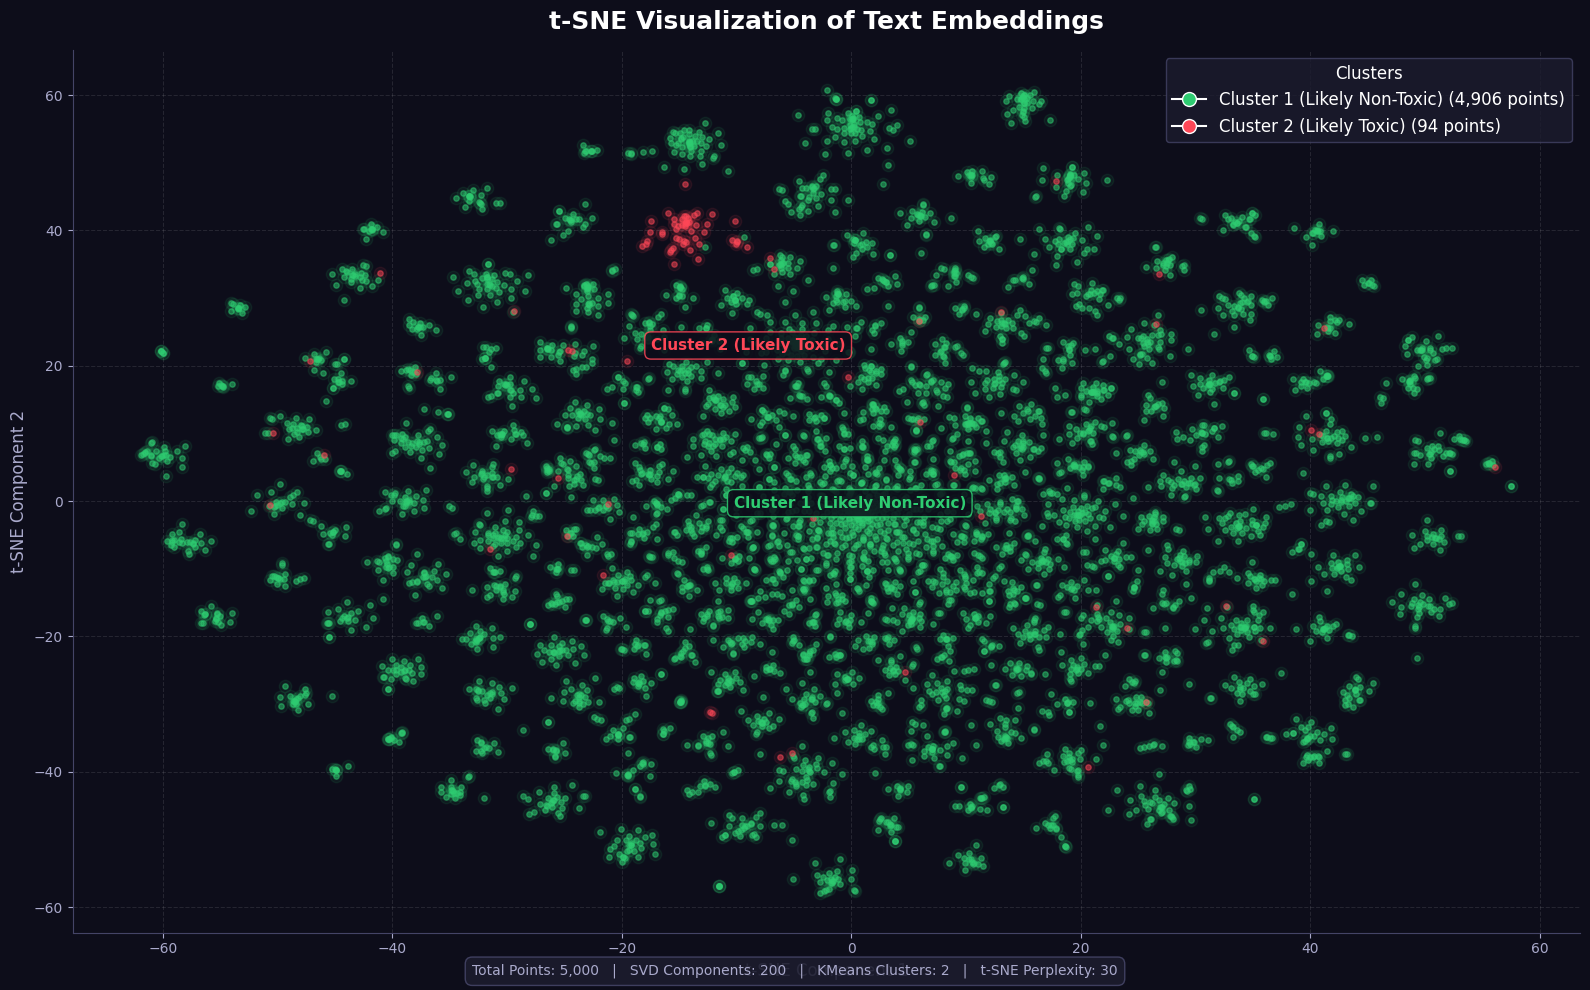

In [5]:
fig, ax = plt.subplots(figsize=(16, 10))
fig.patch.set_facecolor('#0D0D1A')
ax.set_facecolor('#0D0D1A')

colors = {
    'Cluster 1 (Likely Non-Toxic)': '#2ECC71',
    'Cluster 2 (Likely Toxic)': '#FF4757'
}

for cluster, color in colors.items():
    subset = df_tsne[df_tsne['cluster'] == cluster]

    # Glow effect
    ax.scatter(subset['x'], subset['y'],
               c=color, alpha=0.08, s=80, zorder=1)

    # Main scatter
    ax.scatter(subset['x'], subset['y'],
               c=color, alpha=0.5, s=15, zorder=2)

    # Cluster center label
    cx = subset['x'].mean()
    cy = subset['y'].mean()
    ax.text(cx, cy, cluster,
            fontsize=11, fontweight='bold',
            color=color, ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor='#0D0D1A',
                      edgecolor=color, alpha=0.85))

# Styling
ax.grid(True, linestyle='--', alpha=0.1, color='white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#444466')
ax.spines['bottom'].set_color('#444466')
ax.tick_params(colors='#AAAACC')

# Title
plt.title('t-SNE Visualization of Text Embeddings',
          fontsize=18, fontweight='bold', color='white', pad=15)
#plt.suptitle('Cluster Structure — Likely Toxic vs Non-Toxic',
             #fontsize=13, color='#AAAACC', y=0.95)
plt.xlabel('t-SNE Component 1', fontsize=12, color='#AAAACC')
plt.ylabel('t-SNE Component 2', fontsize=12, color='#AAAACC')

# Custom legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=colors[c], markersize=10,
           label=f'{c} ({len(df_tsne[df_tsne["cluster"]==c]):,} points)')
    for c in colors
]
legend = ax.legend(handles=legend_elements, fontsize=12,
                   facecolor='#1C1C2E', labelcolor='white',
                   edgecolor='#444466', loc='upper right',
                   title='Clusters', title_fontsize=12)
legend.get_title().set_color('white')

# Stats box
stats = (f"Total Points: {len(df_tsne):,}   |   "
         f"SVD Components: {len(svd_cols)}   |   "
         f"KMeans Clusters: 2   |   "
         f"t-SNE Perplexity: 30")
fig.text(0.5, 0.02, stats, ha='center', fontsize=10,
         color='#AAAACC',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#1C1C2E',
                   edgecolor='#444466', alpha=0.9))

plt.tight_layout()
plt.show()


#### Insights
 **One dominant cluster exists (Cluster 1 — 4906 points)**: The vast majority of texts are semantically similar to each other, forming one large dense cluster in the center consistent with our earlier finding that ~91.5% of data is non-toxic

### **Visualization - 10 KMeans Cluster Analysis**
To discover thematic groupings and assess alignment with hate labels.



In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
# Extract SVD features
svd_cols = [col for col in df_preprocessed.columns if col.startswith('SVD_')]
X = df_preprocessed[svd_cols].values

# Sample for performance
np.random.seed(42)
idx = np.random.choice(len(X), 10000, replace=False)
X_sample = X[idx]

#  Apply KMeans with k=2
print("Applying KMeans with k=2")
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_sample)

final_score = silhouette_score(X_sample, cluster_labels, sample_size=2000)
print(f"Silhouette Score (k=2): {final_score:.4f}")

# Cluster distribution
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
cluster_counts.index = ['Cluster 1\n(Likely Non-Toxic)',
                         'Cluster 2\n(Likely Toxic)']
print("\nCluster distribution:\n", cluster_counts)

Applying KMeans with k=2
Silhouette Score (k=2): 0.1106

Cluster distribution:
 Cluster 1\n(Likely Non-Toxic)    9350
Cluster 2\n(Likely Toxic)         650
Name: count, dtype: int64


k=2 | Silhouette: 0.1177
k=3 | Silhouette: 0.0738
k=4 | Silhouette: 0.0276
k=5 | Silhouette: -0.0159
k=6 | Silhouette: 0.0305


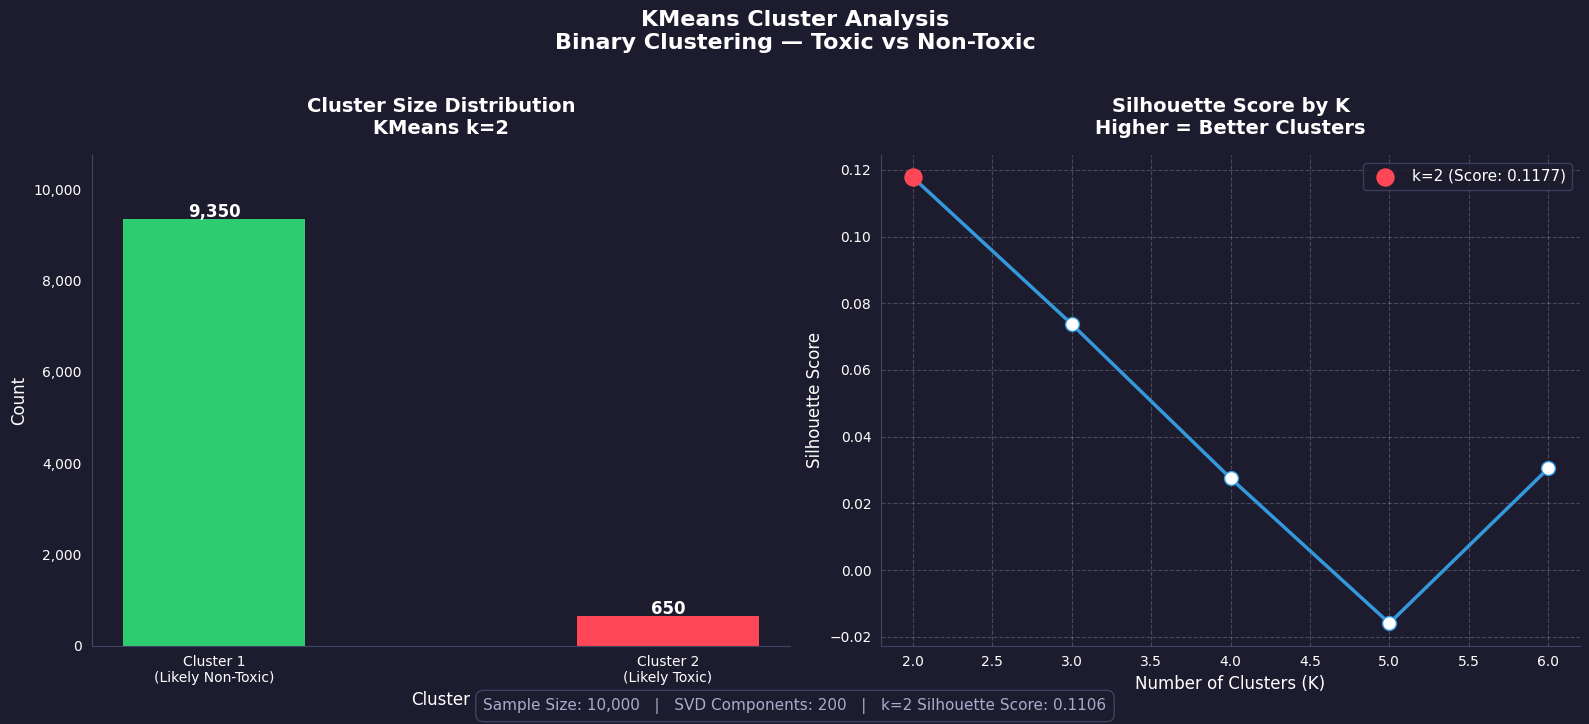

In [ ]:
# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#1C1C2E')


axes[0].set_facecolor('#1C1C2E')
colors = ['#2ECC71', '#FF4757']
bars = axes[0].bar(cluster_counts.index, cluster_counts.values,
                   color=colors, edgecolor='none', width=0.4)

for bar, count in zip(bars, cluster_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 f'{int(count):,}', ha='center',
                 fontsize=12, fontweight='bold', color='white')

axes[0].grid(False)
axes[0].set_title('Cluster Size Distribution\nKMeans k=2',
                  fontsize=14, fontweight='bold', color='white', pad=15)
axes[0].set_xlabel('Cluster', fontsize=12, color='white')
axes[0].set_ylabel('Count', fontsize=12, color='white')
axes[0].tick_params(colors='white')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['left'].set_color('#444466')
axes[0].spines['bottom'].set_color('#444466')
axes[0].set_ylim(0, cluster_counts.max() * 1.15)

axes[1].set_facecolor('#1C1C2E')

# Compare silhouette scores for k=2 to k=6
k_range = range(2, 7)
scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_sample)
    s = silhouette_score(X_sample, km.labels_, sample_size=2000)
    scores.append(s)
    print(f"k={k} | Silhouette: {s:.4f}")

axes[1].plot(list(k_range), scores, 'o-',
             color='#3498DB', linewidth=2.5, markersize=10,
             markerfacecolor='white', markeredgecolor='#3498DB')

# Highlight k=2
axes[1].scatter([2], [scores[0]], color='#FF4757',
                s=150, zorder=5, label=f'k=2 (Score: {scores[0]:.4f})')

axes[1].set_title('Silhouette Score by K\nHigher = Better Clusters',
                  fontsize=14, fontweight='bold', color='white', pad=15)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12, color='white')
axes[1].set_ylabel('Silhouette Score', fontsize=12, color='white')
axes[1].tick_params(colors='white')
axes[1].grid(True, linestyle='--', alpha=0.2, color='white')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_color('#444466')
axes[1].spines['bottom'].set_color('#444466')
axes[1].legend(fontsize=11, facecolor='#1C1C2E',
               labelcolor='white', edgecolor='#444466')

plt.suptitle('KMeans Cluster Analysis\nBinary Clustering — Toxic vs Non-Toxic',
             fontsize=16, fontweight='bold', color='white', y=1.02)

# Stats box
fig.text(0.5, 0.02,
         f"Sample Size: {len(X_sample):,}   |   "
         f"SVD Components: {len(svd_cols)}   |   "
         f"k=2 Silhouette Score: {final_score:.4f}",
         ha='center', fontsize=11, color='#AAAACC',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#1C1C2E',
                   edgecolor='#444466', alpha=0.9))

plt.tight_layout()
plt.show()

#### Insights
**KMeans naturally found toxic vs non-toxic without any labels**, the machine grouped texts in a way that closely matches our actual labels — 93.5% in one group, 6.5% in another

**Cluster sizes match label distribution** - Cluster 1 (9,350) ≈ non-toxic proportion, Cluster 2 (650) ≈ toxic proportion this validates our dataset's class imbalance

 **k=2 is clearly the best** — silhouette score of 0.1177 is highest, confirming binary clustering is the right approach for this problem

 **Score drops consistently after k=2** — adding more clusters only makes things worse, confirming the data has a natural binary structure